# Hopf--Cole Transforms, Soft Legendre Transforms, and Viscous Flows

This notebook generates the panels for two related figures.  The first figure illustrates soft Legendre biconjugation: for two non-convex functions $f$, it compares the lower convex envelope $f^{**}$ with the soft biconjugates $(f^{*,\varepsilon})^{*,\varepsilon}$ for increasing temperatures.  The second figure focuses on the PDE content of the Hopf--Cole transform.  Starting from a smooth initial potential $\phi_0$, we solve
$$
    \partial_t \phi + \frac12 |\partial_x \phi|^2
    = \frac{\varepsilon}{2}\partial_{xx}\phi
$$
by the change of variables $u=\exp(-\phi/\varepsilon)$, which turns the problem into the heat equation $\partial_t u=(\varepsilon/2)\partial_{xx}u$.  The velocity $v=\partial_x\phi$ then solves the viscous Burgers equation.  Colors interpolate from red to blue, as in the rest of the book figures.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import RED, BLUE, LIGHT_GRAY, GRAY, interp_color, figure_dir, save_pdf, setup_matplotlib, box_axes

setup_matplotlib()

NAME = "sinkhorn-hopf-cole-transform"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)


## Soft biconjugates and Hopf--Cole solver

The soft-biconjugate panels use direct stabilized log-sum-exp quadrature for the one-dimensional soft Legendre transform.  The zero-temperature reference is the lower convex envelope of the sampled non-convex function.  Two examples are used: a smooth double-well function and a quadratic trend with oscillations, so that the smoothing effect is visible in both simple and more rugged landscapes.

The PDE panels are computed spectrally on a long periodic interval.  The Burgers velocity is initialized as an almost Gaussian bump (with a tiny compensating offset so that it is the derivative of a periodic potential).  For small viscosity, the decreasing flank of the bump steepens into a shock-like transition; increasing $\varepsilon$ smooths this transition through the Hopf--Cole heat flow.  The final time is deliberately long enough for the viscous damping to be visible.

In [2]:
N = 8192
period = 24.0
x = np.linspace(-period / 2, period / 2, N, endpoint=False)
dx = x[1] - x[0]

# A localized Gaussian velocity bump.  We subtract its tiny periodic mean so
# that it is the derivative of a periodic potential for the Fourier solver.
center = -1.10
sigma = 0.60
amplitude = 1.05
v0 = amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)
v0 -= v0.mean()

# Periodic primitive of v0.  An additive constant is irrelevant for Burgers,
# but shifting phi0 makes exp(-phi0/eps) numerically stable for small eps.
phi0 = np.cumsum(v0) * dx
phi0 -= phi0.mean()
phi0 -= phi0.min()

k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
eps_values = [0.045, 0.14, 0.42]
burgers_eps_values = [0.038, 0.10, 0.24]
times = np.array([0.0, 0.55, 1.05, 1.75, 2.55, 3.60])
time_colors = [interp_color(i / (len(times) - 1)) for i in range(len(times))]
x_window = (-3.25, 4.15)


def solve_hopf_cole(eps):
    """Return phi_t and v_t for the viscous HJ/Burgers system.

    The velocity is evaluated with the stable Cole-Hopf ratio
    v_t=(G_t*(v_0 exp(-phi_0/eps)))/(G_t*exp(-phi_0/eps)),
    which avoids differentiating log(u_t) where u_t is tiny.
    """
    w0 = np.exp(-phi0 / eps)
    w0_hat = np.fft.fft(w0)
    vw0_hat = np.fft.fft(v0 * w0)
    phi_curves = []
    velocity_curves = []
    for t in times:
        heat = np.exp(-0.5 * eps * (k**2) * t)
        u = np.real(np.fft.ifft(w0_hat * heat))
        u = np.maximum(u, 1e-300)
        phi = -eps * np.log(u)
        phi -= phi.min()
        if t == 0:
            v = v0.copy()
        else:
            numerator = np.real(np.fft.ifft(vw0_hat * heat))
            v = numerator / u
        phi_curves.append(phi)
        velocity_curves.append(v)
    return np.array(phi_curves), np.array(velocity_curves)

solutions = {eps: solve_hopf_cole(eps) for eps in burgers_eps_values}

# Shared limits make the viscosity comparison honest across columns.
crop = (x >= x_window[0]) & (x <= x_window[1])
phi_min = min(float(phi[:, crop].min()) for phi, _ in solutions.values())
phi_max = max(float(phi[:, crop].max()) for phi, _ in solutions.values())
v_min = min(float(v[:, crop].min()) for _, v in solutions.values())
v_max = max(float(v[:, crop].max()) for _, v in solutions.values())
phi_pad = 0.06 * (phi_max - phi_min)
v_pad = 0.07 * (v_max - v_min)
phi_ylim = (phi_min - phi_pad, phi_max + phi_pad)
v_ylim = (v_min - v_pad, v_max + v_pad)


In [3]:
def lower_convex_envelope(xgrid, values):
    """Piecewise-linear lower convex envelope of samples on an ordered grid."""
    hull = []
    for i in range(len(xgrid)):
        while len(hull) >= 2:
            i0, i1 = hull[-2], hull[-1]
            slope_01 = (values[i1] - values[i0]) / (xgrid[i1] - xgrid[i0])
            slope_12 = (values[i] - values[i1]) / (xgrid[i] - xgrid[i1])
            if slope_12 <= slope_01:
                hull.pop()
            else:
                break
        hull.append(i)
    hull = np.array(hull)
    return np.interp(xgrid, xgrid[hull], values[hull]), hull


def soft_legendre(values, xgrid, pgrid, eps, dx_value):
    """Stabilized quadrature for f^{*,eps}(p)=eps log int exp((p x-f(x))/eps) dx."""
    scores = (pgrid[:, None] * xgrid[None, :] - values[None, :]) / eps
    max_scores = scores.max(axis=1)
    return eps * (
        max_scores + np.log(np.sum(np.exp(scores - max_scores[:, None]), axis=1) * dx_value)
    )


def soft_biconjugate(values, xgrid, pgrid, eps, dx_value, dp_value):
    f_star = soft_legendre(values, xgrid, pgrid, eps, dx_value)
    scores = (xgrid[:, None] * pgrid[None, :] - f_star[None, :]) / eps
    max_scores = scores.max(axis=1)
    return eps * (
        max_scores + np.log(np.sum(np.exp(scores - max_scores[:, None]), axis=1) * dp_value)
    )


# Two confining non-convex functions: one simple, one more oscillatory.
z = np.linspace(-2.8, 2.8, 1600)
dz = z[1] - z[0]
pgrid = np.linspace(-5.6, 5.6, 2000)
dp = pgrid[1] - pgrid[0]
biconj_eps_values = eps_values
biconj_colors = [interp_color(t) for t in np.linspace(0.0, 1.0, 1 + len(biconj_eps_values))]

simple_f = 0.06 * z**4 - 0.46 * z**2 + 0.18 * z + 0.10 * np.sin(4.5 * z)
complex_f = (
    0.18 * z**2
    + 0.25 * np.sin(3.1 * z + 0.35)
    + 0.12 * np.sin(7.4 * z - 0.25)
    + 0.035 * np.cos(11.5 * z + 0.60)
)


def prepare_biconjugate(values):
    values = values - values.min()
    hard, hull = lower_convex_envelope(z, values)
    curves = [soft_biconjugate(values, z, pgrid, eps, dz, dp) for eps in biconj_eps_values]
    ymin = min(hard.min(), *(curve.min() for curve in curves)) - 0.08
    ymax = max(values.max(), *(curve.max() for curve in curves)) + 0.10
    return {"values": values, "hard": hard, "hull": hull, "curves": curves, "ylim": (ymin, ymax)}


biconj_examples = [prepare_biconjugate(simple_f), prepare_biconjugate(complex_f)]


def draw_time_legend(ax):
    entries = [(r"$t=0$", time_colors[0]), (r"$t=T$", time_colors[-1])]
    x0, x1 = 0.065, 0.155
    y0, dy = 0.88, 0.105
    for i, (label, color) in enumerate(entries):
        y = y0 - i * dy
        ax.plot([x0, x1], [y, y], transform=ax.transAxes, color=color, lw=1.35,
                solid_capstyle="round", clip_on=False)
        ax.text(x1 + 0.025, y, label, transform=ax.transAxes, color=color,
                fontsize=6.2, ha="left", va="center")


def draw_biconjugate_curves(ax, example, *, show_eps_labels=False, show_f_label=True, show_ylabel=True):
    values = example["values"]
    hard = example["hard"]
    curves = example["curves"]
    gap = values - hard
    ax.fill_between(
        z, hard, values, where=gap > 0.012,
        color="#e6e1d8", alpha=0.82, linewidth=0, zorder=0,
    )
    ax.plot(z, values, color="#3f3f3f", lw=1.08, ls=(0, (3.0, 1.9)), alpha=0.92, zorder=2)
    ax.plot(z, hard, color=biconj_colors[0], lw=1.75, zorder=4)
    for curve, color in zip(curves, biconj_colors[1:]):
        ax.plot(z, curve, color=color, lw=1.48, zorder=3)

    if show_f_label:
        x_label = -2.35 if values[np.argmin(np.abs(z + 2.35))] > 0.55 else 0.15
        y_label = values[np.argmin(np.abs(z - x_label))] + 0.10
        ax.text(x_label, y_label, r"$f$", color="#3f3f3f", fontsize=8.0, ha="left", va="center")

    if show_eps_labels:
        label_entries = [
            (r"$\epsilon=0$", biconj_colors[0]),
            (r"$.045$", biconj_colors[1]),
            (r"$.14$", biconj_colors[2]),
            (r"$.42$", biconj_colors[3]),
        ]
        for k, (label, color) in enumerate(label_entries):
            ax.text(0.055, 0.935 - 0.065 * k, label, transform=ax.transAxes,
                    color=color, fontsize=7.1, ha="left", va="center")

    ax.set_xlim(-2.58, 2.58)
    ax.set_ylim(*example["ylim"])
    ax.set_xlabel(r"$x$", labelpad=1.5)
    if show_ylabel:
        ax.set_ylabel(r"value", labelpad=2)
    else:
        ax.set_ylabel("")
    ax.tick_params(labelsize=6.7, pad=1.15)
    box_axes(ax)


def draw_biconjugate_panel(example, filename, *, show_ylabel=True, show_eps_labels=False):
    fig, ax = plt.subplots(figsize=(3.20, 2.24))
    draw_biconjugate_curves(ax, example, show_eps_labels=show_eps_labels, show_f_label=True, show_ylabel=show_ylabel)
    path = OUT / filename
    save_pdf(fig, path, pad_inches=0.035)
    shutil.copy2(path, ARXIV_OUT / f"{NAME}--{filename}")
    plt.close(fig)


def draw_epsilon_panel(eps, filename, *, show_legend=False):
    phi_curves, velocity_curves = solutions[eps]
    fig, (ax_phi, ax_v) = plt.subplots(
        2, 1, figsize=(2.88, 2.52), sharex=True,
        gridspec_kw={"height_ratios": [0.86, 1.16], "hspace": 0.045},
    )

    for color, t, phi, vel in zip(time_colors, times, phi_curves, velocity_curves):
        lw = 1.34 if (t == times[0] or t == times[-1]) else 1.02
        ax_phi.plot(x[crop], phi[crop], color=color, lw=lw)
        ax_v.plot(x[crop], vel[crop], color=color, lw=lw)

    ax_v.axhline(0, color="#cfc6b8", lw=0.55, zorder=0)
    ax_phi.set_xlim(*x_window)
    ax_phi.set_ylim(*phi_ylim)
    ax_v.set_ylim(*v_ylim)
    ax_phi.set_ylabel(r"$\phi_t$", labelpad=2)
    ax_v.set_ylabel(r"$v_t$", labelpad=2)
    ax_v.set_xlabel(r"$x$", labelpad=1.5)
    ax_phi.tick_params(labelbottom=False)
    for ax in (ax_phi, ax_v):
        ax.tick_params(labelsize=6.7, pad=1.15)
        box_axes(ax)
    if show_legend:
        draw_time_legend(ax_phi)

    path = OUT / filename
    save_pdf(fig, path, pad_inches=0.035)
    shutil.copy2(path, ARXIV_OUT / f"{NAME}--{filename}")
    plt.close(fig)


biconj_files = ["biconjugate-simple.pdf", "biconjugate-oscillatory.pdf"]
for j, (example, filename) in enumerate(zip(biconj_examples, biconj_files)):
    draw_biconjugate_panel(example, filename, show_ylabel=(j == 0), show_eps_labels=(j == 0))

burgers_files = ["burgers-epsilon-small.pdf", "burgers-epsilon-medium.pdf", "burgers-epsilon-large.pdf"]
for j, (eps, filename) in enumerate(zip(burgers_eps_values, burgers_files)):
    draw_epsilon_panel(eps, filename, show_legend=(j == 0))

def save_biconjugate_thumbnail(filename):
    fig = plt.figure(figsize=(6.6, 2.55))
    gs = fig.add_gridspec(1, 2, wspace=0.10)
    for col, example in enumerate(biconj_examples):
        ax = fig.add_subplot(gs[0, col])
        draw_biconjugate_curves(ax, example, show_eps_labels=False, show_f_label=False, show_ylabel=(col == 0))
        ax.set_xticks([])
        ax.set_yticks([])
    fig.subplots_adjust(left=0.035, right=0.992, bottom=0.075, top=0.975)
    fig.savefig(THUMB_DIR / filename, dpi=190)
    plt.close(fig)


def save_burgers_thumbnail(filename):
    fig = plt.figure(figsize=(7.8, 2.75))
    gs = fig.add_gridspec(2, 3, wspace=0.105, hspace=0.055)
    for col, eps in enumerate(burgers_eps_values):
        phi_curves, velocity_curves = solutions[eps]
        ax_phi = fig.add_subplot(gs[0, col])
        ax_v = fig.add_subplot(gs[1, col], sharex=ax_phi)
        for color, phi, vel in zip(time_colors, phi_curves, velocity_curves):
            ax_phi.plot(x[crop], phi[crop], color=color, lw=0.95)
            ax_v.plot(x[crop], vel[crop], color=color, lw=0.95)
        ax_v.axhline(0, color="#cfc6b8", lw=0.5, zorder=0)
        ax_phi.set_ylim(*phi_ylim)
        ax_v.set_ylim(*v_ylim)
        ax_phi.set_title(rf"$\varepsilon={eps:g}$", fontsize=8, pad=2.5)
        ax_phi.tick_params(labelbottom=False)
        for ax in (ax_phi, ax_v):
            ax.set_xlim(*x_window)
            ax.set_xticks([])
            ax.set_yticks([])
            box_axes(ax)
    fig.subplots_adjust(left=0.022, right=0.992, bottom=0.075, top=0.900)
    fig.savefig(THUMB_DIR / filename, dpi=190)
    plt.close(fig)


save_biconjugate_thumbnail("sinkhorn-soft-biconjugates.png")
save_burgers_thumbnail("sinkhorn-burgers-hopf-cole.png")

# Thumbnail for the searchable notebook gallery: both figures in one compact preview.
fig = plt.figure(figsize=(11.4, 3.55))
gs = fig.add_gridspec(2, 5, width_ratios=[1.08, 1.08, 1, 1, 1], wspace=0.105, hspace=0.055)
for col, example in enumerate(biconj_examples):
    ax_bi = fig.add_subplot(gs[:, col])
    draw_biconjugate_curves(ax_bi, example, show_eps_labels=False, show_f_label=False, show_ylabel=False)
    ax_bi.set_xticks([])
    ax_bi.set_yticks([])

for col, eps in enumerate(burgers_eps_values, start=2):
    phi_curves, velocity_curves = solutions[eps]
    ax_phi = fig.add_subplot(gs[0, col])
    ax_v = fig.add_subplot(gs[1, col], sharex=ax_phi)
    for color, phi, vel in zip(time_colors, phi_curves, velocity_curves):
        ax_phi.plot(x[crop], phi[crop], color=color, lw=0.95)
        ax_v.plot(x[crop], vel[crop], color=color, lw=0.95)
    ax_v.axhline(0, color="#cfc6b8", lw=0.5, zorder=0)
    ax_phi.set_ylim(*phi_ylim)
    ax_v.set_ylim(*v_ylim)
    ax_phi.set_title(rf"$\varepsilon={eps:g}$", fontsize=8, pad=2.5)
    ax_phi.tick_params(labelbottom=False)
    for ax in (ax_phi, ax_v):
        ax.set_xlim(*x_window)
        ax.set_xticks([])
        ax.set_yticks([])
        box_axes(ax)
fig.subplots_adjust(left=0.022, right=0.992, bottom=0.055, top=0.915)
fig.savefig(THUMB_DIR / f"{NAME}.png", dpi=190)
plt.close(fig)

print(f"Wrote panels to {OUT}")


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Wrote panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/sinkhorn-hopf-cole-transform


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

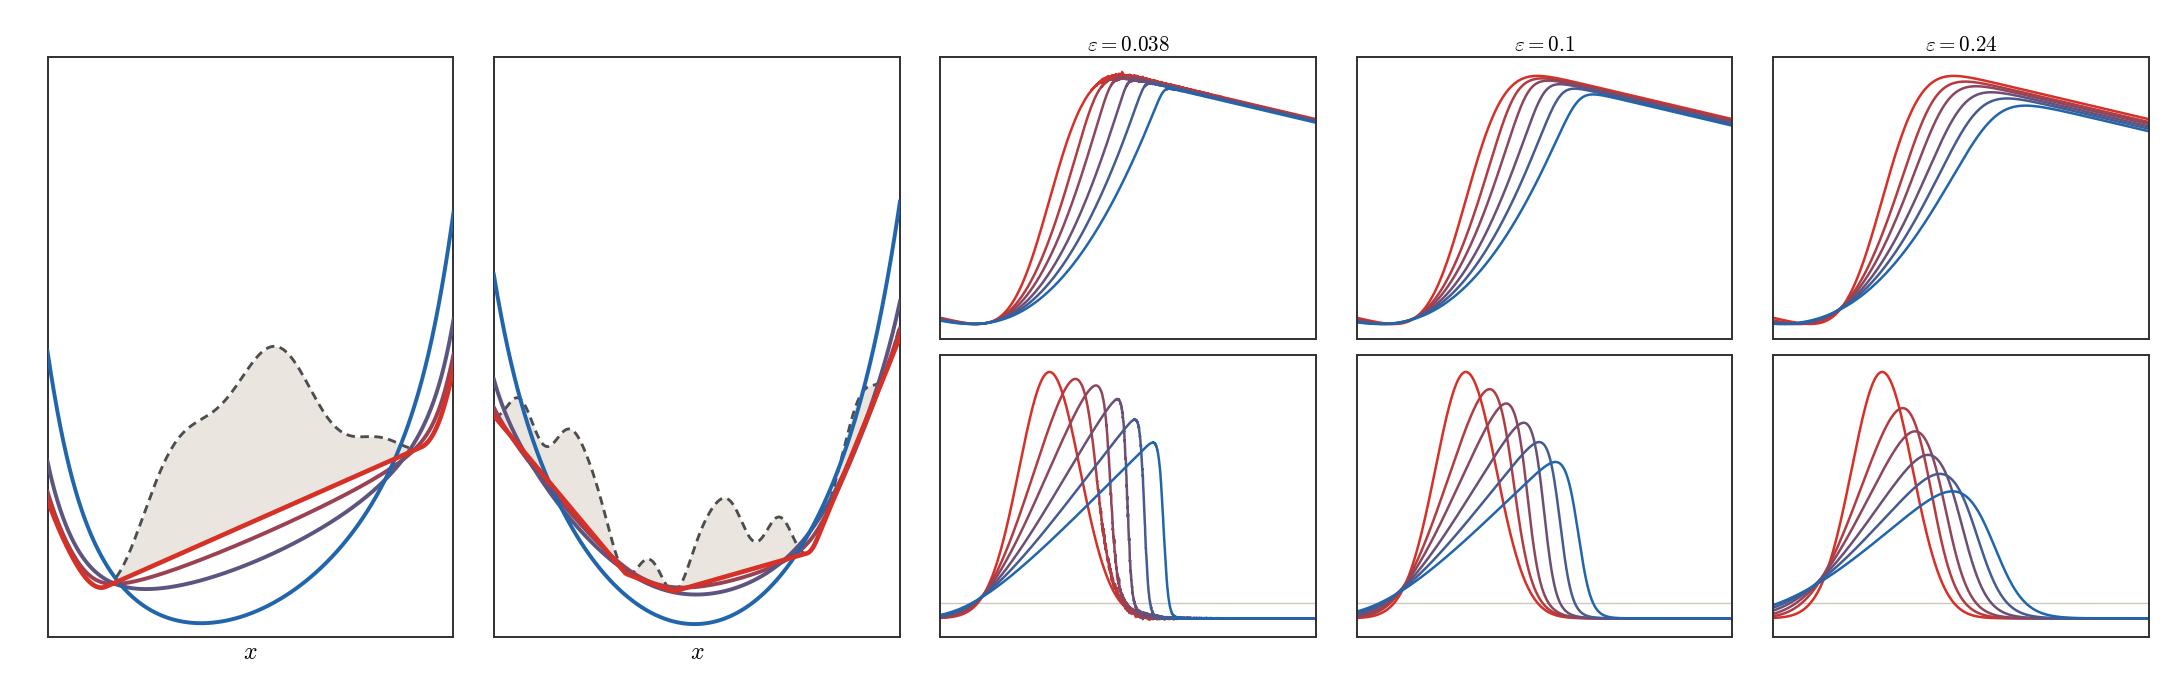

In [4]:
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-hopf-cole-transform.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-hopf-cole-transform.png")
display(Image(filename=str(_thumb)))
